# Bird Image Generation - DCGAN vs. cDCGAN vs. Stable Diffusion (LoRA)

Comparative study of generative models trained on the **CUB-200-2011** dataset (200 bird species, ~11,788 images).

| Model | Type | Resolution | Conditioning |
|---|---|---|---|
| DCGAN | Unconditional GAN | 64×64 | None |
| cDCGAN | Conditional GAN | 64×64 | Class label |
| Stable Diffusion + LoRA | Diffusion Model | 256×256 | Text prompt |

## Setup

Mount Google Drive, extract the CUB-200-2011 dataset, and install required dependencies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/Birds/archive-2.zip -d /content/Birds

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: /content/Birds/segmentations/116.Chipping_Sparrow/Chipping_Sparrow_0109_108162.png  
  inflating: /content/Birds/segmentations/116.Chipping_Sparrow/Chipping_Sparrow_0110_108974.png  
  inflating: /content/Birds/segmentations/116.Chipping_Sparrow/Chipping_Sparrow_0111_108515.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0001_110632.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0002_110606.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0003_110672.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0005_110911.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0008_110536.png  
  inflating: /content/Birds/segmentations/117.Clay_colored_Sparrow/Clay_Colored_Sparrow_0009_797256.png  
  inf

In [ ]:
!pip install pytorch-fid torchmetrics
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

## 1. DCGAN - Unconditional

Unconditional GAN with a 100-dimensional noise vector input, producing 64×64 RGB images. The Generator uses 5 transposed convolutional layers; the Discriminator uses 5 convolutional layers. Trained with BCELoss and soft label smoothing.

In [ ]:

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.utils.data import DataLoader

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch.nn.functional as F

class BirdDataset(Dataset):
    def __init__(self, images_txt_path, labels_txt_path, image_root, transform=None):
        self.transform = transform
        self.image_root = image_root

        with open(images_txt_path, 'r') as f:
            lines = f.readlines()
            self.image_paths = {int(line.split()[0]): line.strip().split()[1] for line in lines}

        with open(labels_txt_path, 'r') as f:
            lines = f.readlines()
            self.image_labels = {int(line.split()[0]): int(line.strip().split()[1]) - 1 for line in lines}

        self.indices = sorted(self.image_paths.keys())

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        index = self.indices[idx]
        img_path = os.path.join(self.image_root, self.image_paths[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        class_id = self.image_labels[index]
        return image, class_id

# === Generator ===
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 5, 2, 2, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# === Discriminator ===
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 5, 2, 2, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 5, 2, 2, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 5, 2, 2, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 5, 2, 2, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(4 * 4 * 512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# === Display Generated Images ===
def show_example_images(generator, device, epoch):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(3, 100, 1, 1, device=device)
        generated = generator(noise).cpu()
        plt.figure(figsize=(9, 3))
        for i in range(3):
            plt.subplot(1, 3, i + 1)
            img = generated[i].numpy().transpose(1, 2, 0)
            img = ((img + 1) * 127.5).astype(np.uint8)
            plt.imshow(img)
            plt.axis("off")
        plt.suptitle(f"Generated Samples - Epoch {epoch + 1}")
        plt.tight_layout()
        plt.show()
    generator.train()


# === Compute FID and IS ===
def compute_fid_is(generator, dataloader, device, batch_size=128, num_images=500):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    inception = InceptionScore().to(device)
    generator.eval()
    dataloader_iter = iter(dataloader)
    collected = 0

    with torch.no_grad():
        while collected < num_images:
            try:
                real_batch, _ = next(dataloader_iter)
            except StopIteration:
                dataloader_iter = iter(dataloader)
                real_batch, _ = next(dataloader_iter)

            bs = min(batch_size, num_images - collected)
            real_imgs = real_batch[:bs].to(device)
            z = torch.randn(bs, 100, 1, 1, device=device)
            gen_labels = torch.randint(0, 200, (bs,), device=device)  # num_classes = 200
            gen_imgs = generator(z.squeeze(), gen_labels)

            def to_uint8(tensor):
                tensor = (tensor * 0.5 + 0.5) * 255
                return tensor.clamp(0, 255).byte()

            real_resized = to_uint8(F.interpolate(real_imgs, size=(299, 299)))
            fake_resized = to_uint8(F.interpolate(gen_imgs, size=(299, 299)))

            fid.update(real_resized, real=True)
            fid.update(fake_resized, real=False)
            inception.update(fake_resized)

            collected += bs

    fid_score = fid.compute().item()
    is_score = inception.compute()[0].item()

    generator.train()
    return fid_score, is_score


# === MAIN ===
def main():
    dataset_path = "/content/Birds/CUB_200_2011/images"
    image_size = 64
    batch_size = 128
    epochs = 150
    load_epoch = None

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = dsets.ImageFolder(root=dataset_path, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    generator = Generator().to(device)
    discriminator = Discriminator().to(device)

    # === Optional: Load Pre-Trained Models ===
    if load_epoch is not None:
        gen_path = f"models/generators/generator_epoch{load_epoch}.pt"
        disc_path = f"models/discriminators/discriminator_epoch{load_epoch}.pt"
        if os.path.exists(gen_path) and os.path.exists(disc_path):
            generator.load_state_dict(torch.load(gen_path, map_location=device))
            discriminator.load_state_dict(torch.load(disc_path, map_location=device))
            print(f"Loaded models from epoch {load_epoch}")
        else:
            print(f"Model files not found for epoch {load_epoch}")
        start_epoch = load_epoch + 1
    else:
        start_epoch = 0

    adversarial_loss = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=0.00015, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    G_losses, D_losses = [], []

    # CSV log
    log_path = "metrics_log.csv"
    if not os.path.exists(log_path):
        with open(log_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Epoch", "G_Loss", "D_Loss", "FID", "IS", "Duration"])

    for epoch in range(start_epoch, epochs):
        epoch_start = time.time()
        print(f"Epoch {epoch+1}/{epochs}:")

        for i, (real_imgs, _) in enumerate(dataloader):
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            valid = torch.ones(bs, 1, device=device) * (1 - torch.rand(bs, 1, device=device) * 0.2)
            fake = torch.rand(bs, 1, device=device) * 0.2

            # === Train Discriminator ===
            noise = torch.randn(bs, 100, 1, 1, device=device)
            fake_imgs = generator(noise)
            optimizer_D.zero_grad()
            d_loss = adversarial_loss(discriminator(real_imgs), valid) + \
                     adversarial_loss(discriminator(fake_imgs.detach()), fake)
            d_loss.backward()
            optimizer_D.step()

            # === Train Generator ===
            noise = torch.randn(bs * 2, 100, 1, 1, device=device)
            valid = torch.ones(bs * 2, 1, device=device) * (1 - torch.rand(bs * 2, 1, device=device) * 0.2)
            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(noise)), valid)
            g_loss.backward()
            optimizer_G.step()

            G_losses.append(g_loss.item())
            D_losses.append(d_loss.item())

            if i == len(dataloader) - 1:
                print(f"  Batch {i+1}/{len(dataloader)} - D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        epoch_duration = time.time() - epoch_start

        if (epoch + 1) % 10 == 0 or (epoch + 1) == 1:
            fid_score, inception_score = compute_fid_is(generator, dataloader, device)
            print(f"[FID: {fid_score:.2f}] [IS: {inception_score:.2f}]")
        else:
            fid_score, inception_score = None, None

        show_example_images(generator, device, epoch)

        # Log metrics to CSV
        with open(log_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                g_loss.item(),
                d_loss.item(),
                round(fid_score, 4) if fid_score is not None else "",
                round(inception_score, 4) if inception_score is not None else "",
                round(epoch_duration, 2)
            ])

        # Save model checkpoints
        if (epoch + 1) % 10 == 0:
          os.makedirs("models/generators", exist_ok=True)
          os.makedirs("models/discriminators", exist_ok=True)
          torch.save(generator.state_dict(), f"models/generators/generator_epoch{epoch}.pt")
          torch.save(discriminator.state_dict(), f"models/discriminators/discriminator_epoch{epoch}.pt")
          # torch.save(generator.state_dict(), f"models/generators/generator_latest.pt")
          # torch.save(discriminator.state_dict(), f"models/discriminators/discriminator_latest.pt")

        plt.figure()
        plt.plot(G_losses, label='Generator Loss', color='green')
        plt.plot(D_losses, label='Discriminator Loss', color='blue')
        plt.title("DCGAN Train")
        plt.xlabel("Batch Iteration")
        plt.ylabel("Loss")
        plt.legend()
        plt.close()


if __name__ == "__main__":
    main()


## 2. Conditional DCGAN (cDCGAN)

Conditional GAN conditioned on class labels (200 bird species). The Generator concatenates a noise vector with a class embedding; the Discriminator takes the image plus a projected label map as a 4-channel input.

In [ ]:
# PyTorch version of the provided Keras DCGAN training script

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import csv

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as dsets
from torch.utils.data import DataLoader

# from torchmetrics.image.fid import FrechetInceptionDistance
# from torchmetrics.image.inception import InceptionScore
import torch.nn.functional as F

from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
from PIL import Image

class BirdDataset(Dataset):
    def __init__(self, images_txt_path, labels_txt_path, image_root, transform=None):
        self.transform = transform
        self.image_root = image_root

        with open(images_txt_path, 'r') as f:
            lines = f.readlines()
            self.image_paths = {int(line.split()[0]): line.strip().split()[1] for line in lines}

        with open(labels_txt_path, 'r') as f:
            lines = f.readlines()
            self.image_labels = {int(line.split()[0]): int(line.strip().split()[1]) - 1 for line in lines}

        self.indices = sorted(self.image_paths.keys())

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        index = self.indices[idx]
        img_path = os.path.join(self.image_root, self.image_paths[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        class_id = self.image_labels[index]
        return image, class_id

# === Generator ===
class Generator(nn.Module):
    def __init__(self, noise_dim=100, class_dim=200):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(class_dim, class_dim)
        self.input = nn.Linear(noise_dim + class_dim, 4 * 4 * 512)

        self.model = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 5, 2, 2, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat((noise, label_embedding), dim=1)
        x = self.input(x)
        x = x.view(x.size(0), 512, 4, 4)
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self, class_dim=200):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(class_dim, class_dim)
        self.label_proj = nn.Linear(class_dim, 64 * 64)

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 5, 2, 2, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 5, 2, 2, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 5, 2, 2, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 5, 2, 2, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(4 * 4 * 512, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_embedding = self.label_emb(labels)
        label_map = self.label_proj(label_embedding).view(-1, 1, 64, 64)
        x = torch.cat((img, label_map), dim=1)
        return self.model(x)



# === Display Generated Images ===
def show_example_images(generator, device, epoch, num_classes, batch_size):
    generator.eval()
    with torch.no_grad():
        labels = torch.randint(0, num_classes, (batch_size,), device=device)
        noise = torch.randn(batch_size, 100, device=device)
        generated = generator(noise, labels)
        plt.figure(figsize=(9, 3))
        for i in range(3):
            plt.subplot(1, 3, i + 1)
            img = generated[i].cpu().numpy().transpose(1, 2, 0)  # Move to CPU before numpy()
            img = ((img + 1) * 127.5).astype(np.uint8)
            plt.imshow(img)
            plt.axis("off")
        plt.suptitle(f"Generated Samples - Epoch {epoch + 1}")
        plt.tight_layout()
        plt.show()
    generator.train()


# === Compute FID and IS ===
def compute_fid_is(generator, dataloader, num_classes, device, batch_size=128, num_images=500):
    fid = FrechetInceptionDistance(feature=2048).to(device)
    inception = InceptionScore().to(device)
    generator.eval()
    dataloader_iter = iter(dataloader)
    collected = 0

    with torch.no_grad():
        while collected < num_images:
            try:
                real_batch, _ = next(dataloader_iter)
            except StopIteration:
                dataloader_iter = iter(dataloader)
                real_batch, _ = next(dataloader_iter)

            bs = min(batch_size, num_images - collected)
            real_imgs = real_batch[:bs].to(device)
            z = torch.randn(bs, 100, device=device)
            gen_labels = torch.randint(0, num_classes, (bs,), device=device)
            gen_imgs = generator(z, gen_labels)


            def to_uint8(tensor):
                tensor = (tensor * 0.5 + 0.5) * 255
                return tensor.clamp(0, 255).byte()

            real_resized = to_uint8(F.interpolate(real_imgs, size=(299, 299)))
            fake_resized = to_uint8(F.interpolate(gen_imgs, size=(299, 299)))

            fid.update(real_resized, real=True)
            fid.update(fake_resized, real=False)
            inception.update(fake_resized)

            collected += bs

    fid_score = fid.compute().item()
    is_score = inception.compute()[0].item()

    generator.train()
    return fid_score, is_score


# === MAIN ===
def main():
    dataset_path = "/content/Birds/CUB_200_2011/images"
    image_size = 64
    batch_size = 128
    epochs = 150
    load_epoch = None
    num_classes = 200

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # dataset = BirdDataset(
    # images_txt_path="/content/Birds/CUB_200_2011/images.txt",
    # labels_txt_path="/content/Birds/CUB_200_2011/image_class_labels.txt",
    # image_root="/content/Birds/CUB_200_2011/images",
    # transform=transform
    # )

    # dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    generator = Generator(class_dim=num_classes).to(device)
    discriminator = Discriminator(class_dim=num_classes).to(device)

    # === Optional: Load Pre-Trained Models ===
    if load_epoch is not None:
        gen_path = f"models/generators/generator_epoch{load_epoch}.pt"
        disc_path = f"models/discriminators/discriminator_epoch{load_epoch}.pt"
        if os.path.exists(gen_path) and os.path.exists(disc_path):
            generator.load_state_dict(torch.load(gen_path, map_location=device))
            discriminator.load_state_dict(torch.load(disc_path, map_location=device))
            print(f"Loaded models from epoch {load_epoch}")
        else:
            print(f"Model files not found for epoch {load_epoch}")
        start_epoch = load_epoch + 1
    else:
        start_epoch = 0

    adversarial_loss = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=0.00015, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

    G_losses, D_losses = [], []

    # CSV log
    log_path = "metrics_log.csv"
    if not os.path.exists(log_path):
        with open(log_path, mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(["Epoch", "G_Loss", "D_Loss", "FID", "IS", "Duration"])

    for epoch in range(start_epoch, epochs):
        epoch_start = time.time()
        print(f"Epoch {epoch+1}/{epochs}:")

        for i, (real_imgs, real_labels) in enumerate(dataloader):
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            valid = torch.ones(bs, 1, device=device) * (1 - torch.rand(bs, 1, device=device) * 0.2)
            fake = torch.rand(bs, 1, device=device) * 0.2

            # === Train Discriminator ===
            real_imgs = real_imgs.to(device)
            real_labels = real_labels.to(device)
            bs = real_imgs.size(0)

            valid = torch.ones(bs, 1, device=device)
            fake = torch.zeros(bs, 1, device=device)

            z = torch.randn(bs, 100, device=device)
            gen_labels = torch.randint(0, num_classes, (bs,), device=device)
            fake_imgs = generator(z, gen_labels)

            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs, real_labels), valid)
            fake_loss = adversarial_loss(discriminator(fake_imgs.detach(), gen_labels), fake)
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()


            # === Train Generator ===
            z = torch.randn(bs, 100, device=device)
            gen_labels = torch.randint(0, num_classes, (bs,), device=device)

            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(z, gen_labels), gen_labels), valid)
            g_loss.backward()
            optimizer_G.step()

            G_losses.append(g_loss.item())
            D_losses.append(d_loss.item())

            if i == len(dataloader) - 1:
                print(f"  Batch {i+1}/{len(dataloader)} - D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        epoch_duration = time.time() - epoch_start

        # Every 10 epochs: compute FID and IS
        if (epoch + 1) % 10 == 0 or (epoch + 1) == 1:
            fid_score, inception_score = compute_fid_is(generator, dataloader, num_classes, device)
            print(f"[FID: {fid_score:.2f}] [IS: {inception_score:.2f}]")
        else:
            fid_score, inception_score = None, None

        show_example_images(generator, device, epoch, num_classes, batch_size)

        # Log metrics to CSV
        with open(log_path, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                g_loss.item(),
                d_loss.item(),
                round(fid_score, 4) if fid_score is not None else "",
                round(inception_score, 4) if inception_score is not None else "",
                round(epoch_duration, 2)
            ])

        # Save model checkpoints
        if (epoch + 1) % 10 == 0:
          os.makedirs("models/generators", exist_ok=True)
          os.makedirs("models/discriminators", exist_ok=True)
          torch.save(generator.state_dict(), f"models/generators/generator_epoch{epoch}.pt")
          torch.save(discriminator.state_dict(), f"models/discriminators/discriminator_epoch{epoch}.pt")
          # torch.save(generator.state_dict(), f"models/generators/generator_latest.pt")
          # torch.save(discriminator.state_dict(), f"models/discriminators/discriminator_latest.pt")

        # Loss curve plot
        plt.figure()
        plt.plot(G_losses, label='Generator Loss', color='green')
        plt.plot(D_losses, label='Discriminator Loss', color='blue')
        plt.title("DCGAN Train")
        plt.xlabel("Batch Iteration")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"loss_plot_epoch{epoch + 1}.png")
        plt.close()


if __name__ == "__main__":
    main()


## Architecture Visualization

Generate PDF visualizations of the Generator and Discriminator architectures using `torchviz`.

In [ ]:
!pip install visualtorch

In [ ]:
import torch
from torchviz import make_dot

model = Generator()
model.eval()

noise = torch.randn(1, 100)               # batch size 1, noise dim 100
labels = torch.randint(0, 200, (1,))      # batch size 1, class index

# Forward pass
output = model(noise, labels)

dot = make_dot(output, params=dict(model.named_parameters()))

dot.render("generator_model", format="pdf")
print("Generated file generator_model.pdf")


In [ ]:
!apt-get install -y graphviz
!pip install torchviz

In [ ]:
visualize_generator_architecture()

In [ ]:
pip install --upgrade --force-reinstall visualtorch


## 3. Stable Diffusion Fine-Tuning (LoRA)

### 3.1 Training

Fine-tunes Stable Diffusion v1.5 on CUB-200-2011 using Low-Rank Adaptation (LoRA). LoRA rank=4, target modules: `to_q`, `to_k`, `to_v`, `to_out.0`. Training uses FP16 mixed precision via Accelerate over 20 epochs at 256×256 resolution.

In [ ]:
!pip install diffusers transformers peft accelerate datasets torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 69.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
login(os.environ["HF_TOKEN"])  # find your token at: https://huggingface.co/settings/tokens


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()
# HF_TOKEN is now available via os.environ["HF_TOKEN"]


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
Epoch 1/20: 100%|██████████| 369/369 [09:46<00:00,  1.59s/it, loss=0.192]
/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/model.py:365: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  return getattr(self.model, name)


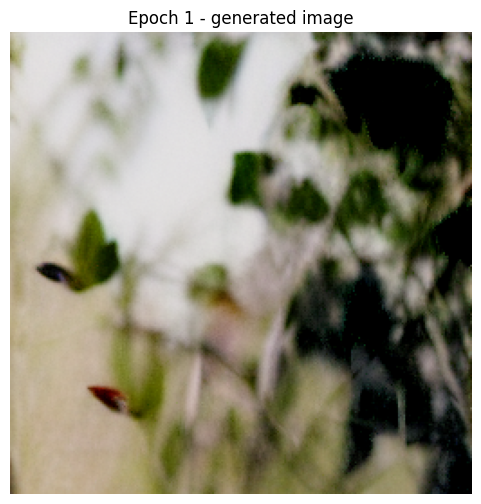

Epoch 2/20: 100%|██████████| 369/369 [09:46<00:00,  1.59s/it, loss=0.097]


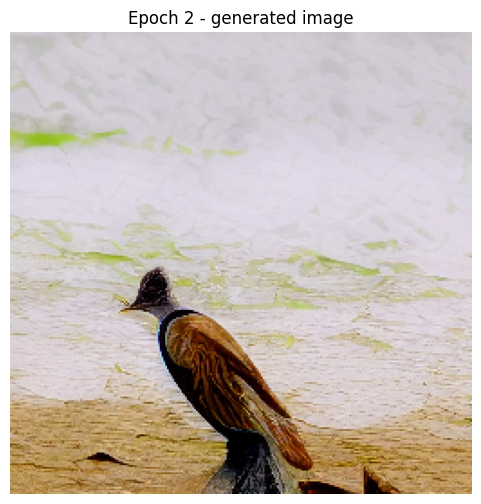

Epoch 3/20: 100%|██████████| 369/369 [09:43<00:00,  1.58s/it, loss=0.134]


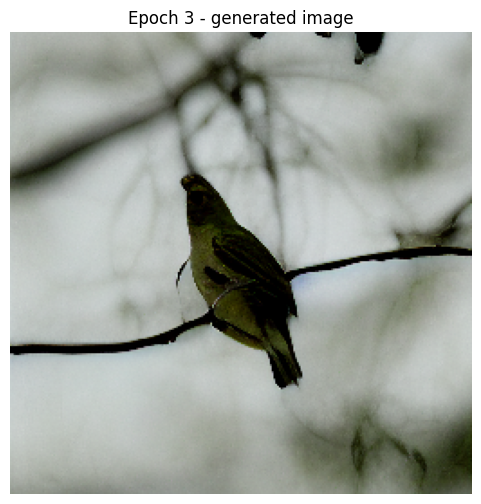

Epoch 4/20: 100%|██████████| 369/369 [09:41<00:00,  1.58s/it, loss=0.205]


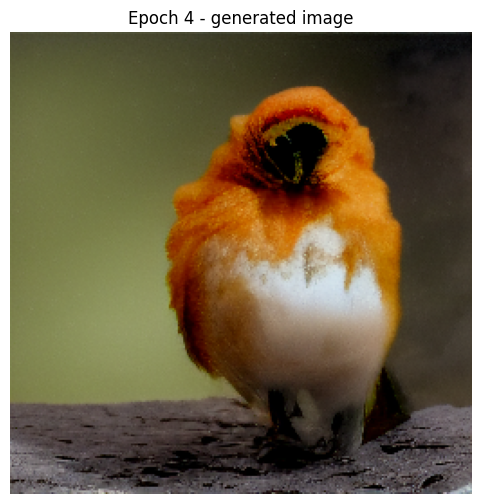

Epoch 5/20: 100%|██████████| 369/369 [09:41<00:00,  1.58s/it, loss=0.174]


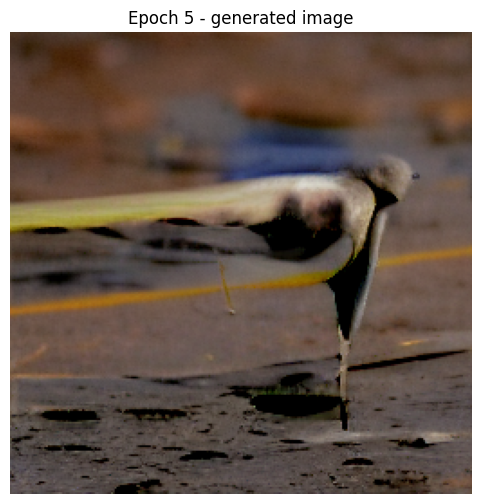

Epoch 6/20: 100%|██████████| 369/369 [09:41<00:00,  1.58s/it, loss=0.147]


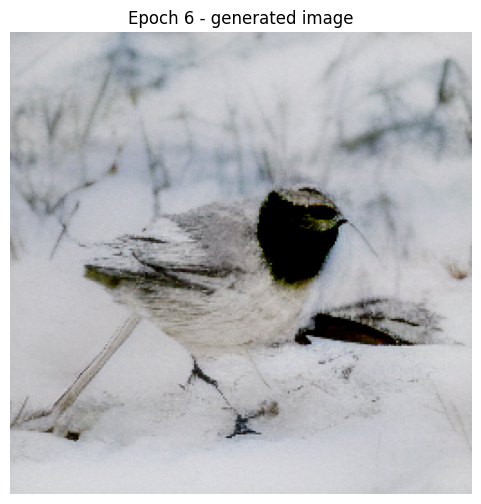

Epoch 7/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.188]


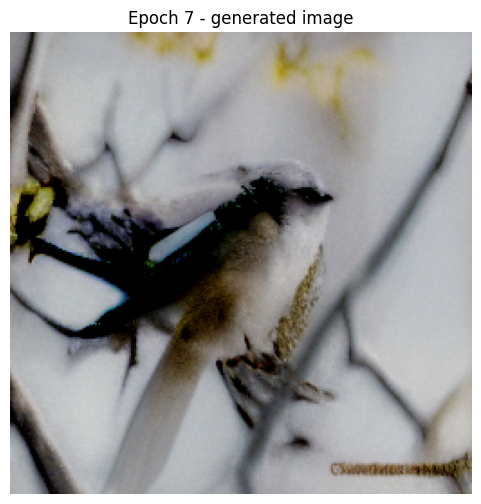

Epoch 8/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.105]


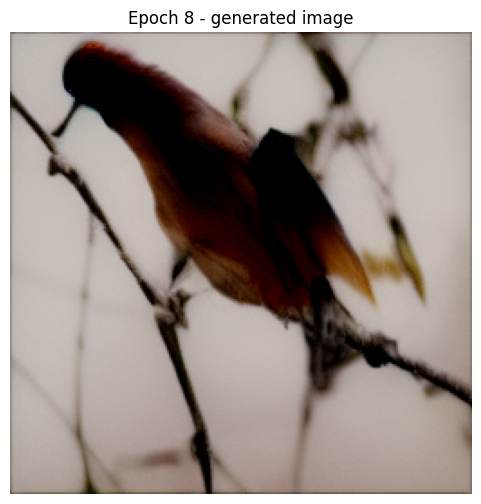

Epoch 9/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.141]


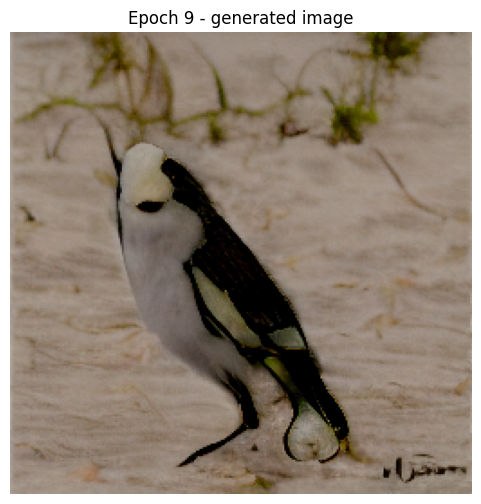

Epoch 10/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.183]


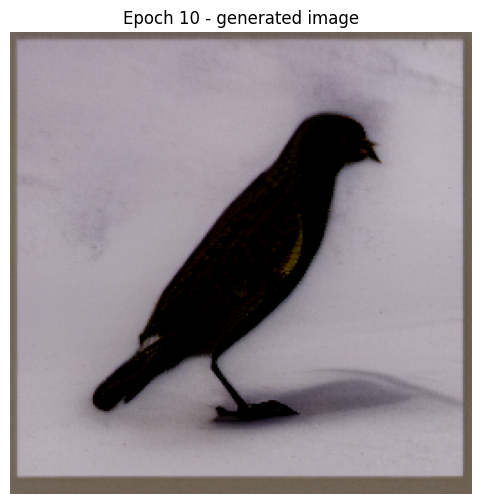

Epoch 11/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.124]


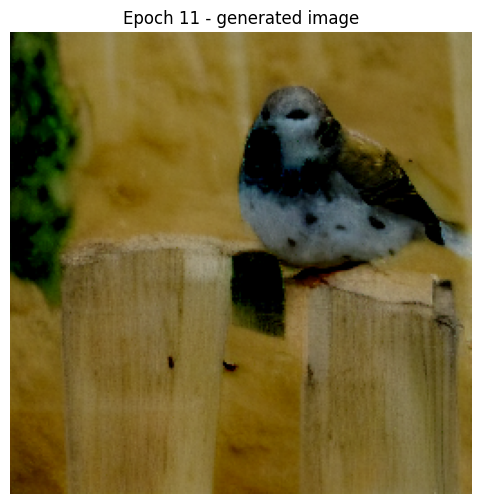

Epoch 12/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.198]


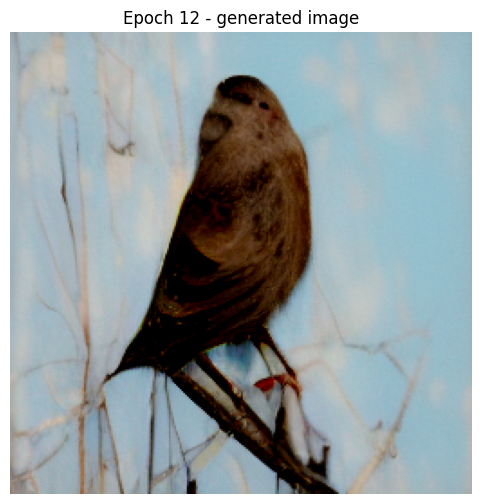

Epoch 13/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.21]


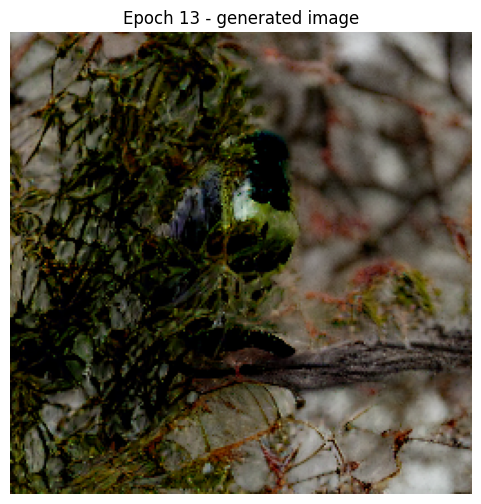

Epoch 14/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.187]


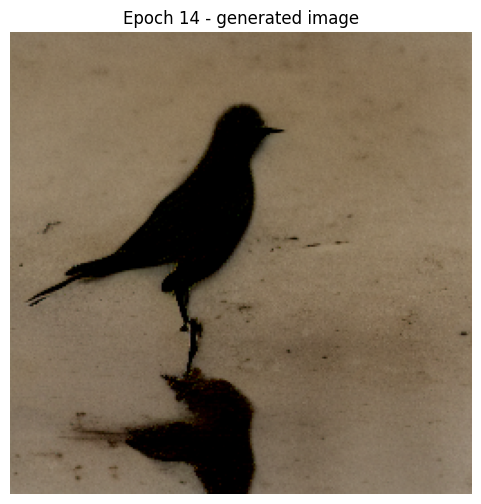

Epoch 15/20: 100%|██████████| 369/369 [09:43<00:00,  1.58s/it, loss=0.157]


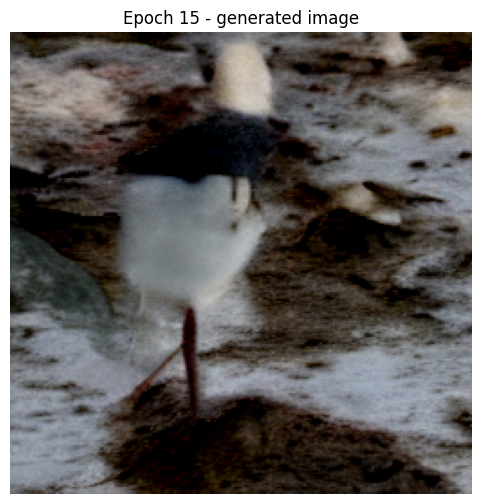

Epoch 16/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.149]


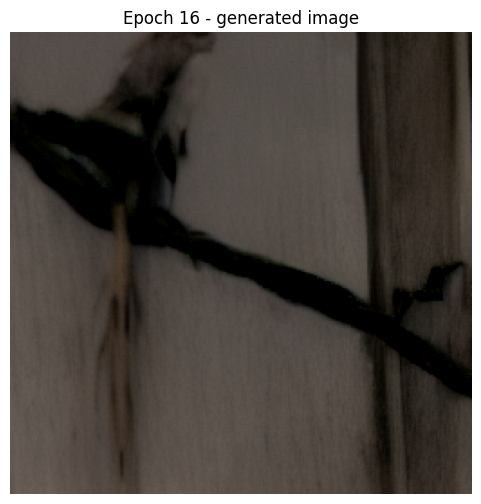

Epoch 17/20: 100%|██████████| 369/369 [09:42<00:00,  1.58s/it, loss=0.229]


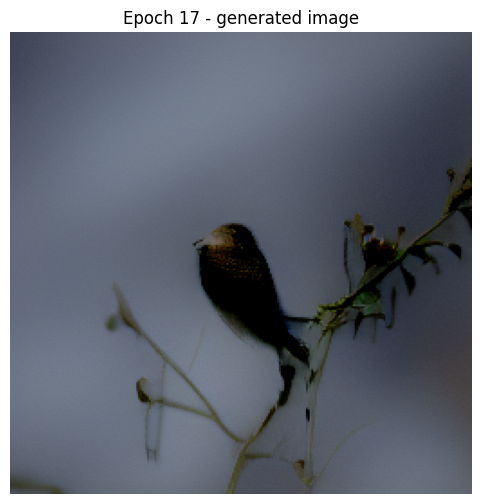

Epoch 18/20: 100%|██████████| 369/369 [09:43<00:00,  1.58s/it, loss=0.121]


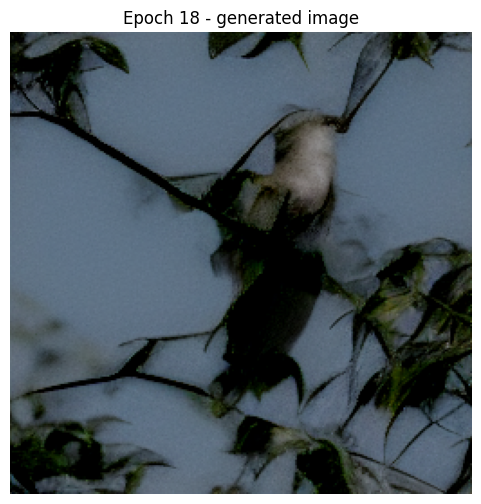

Epoch 19/20: 100%|██████████| 369/369 [09:43<00:00,  1.58s/it, loss=0.134]


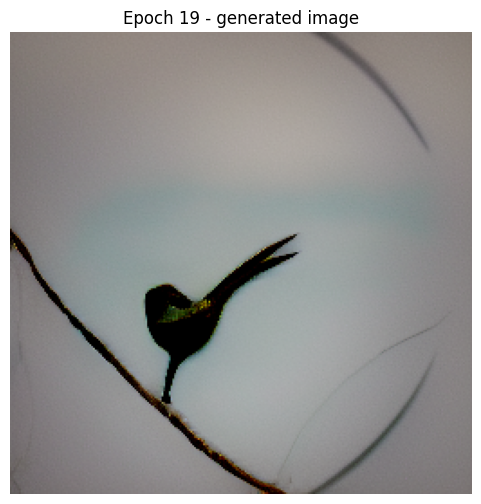

Epoch 20/20: 100%|██████████| 369/369 [09:43<00:00,  1.58s/it, loss=0.14]


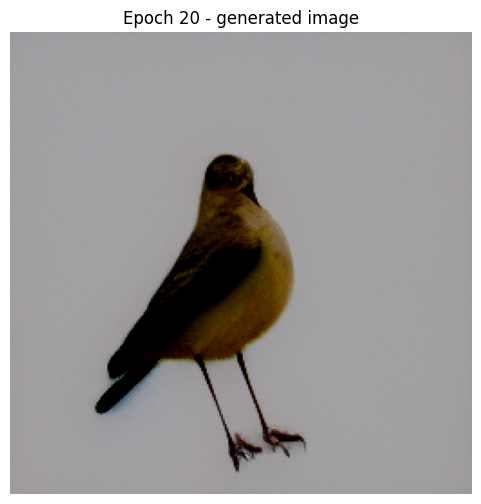

✅ Trening zakończony.


In [ ]:
import os
import torch
from datasets import load_dataset
from diffusers import StableDiffusionPipeline, DDPMScheduler, UNet2DConditionModel, AutoencoderKL
from transformers import CLIPTokenizer, CLIPTextModel
from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
from accelerate import Accelerator
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import csv
import time
import gc


# Configuration
output_dir = "./lora-sd15-cub200"
image_size = 256
batch_size = 32
epochs = 20
lr = 1e-4
rank = 4  # LoRA rank
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")


# LoRA configuration
lora_config = LoraConfig(
    r=rank,
    lora_alpha=rank * 2,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.1,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

# CUB-200 Dataset
class CUB200Dataset(Dataset):
    def __init__(self, image_dir, tokenizer, transform, class_map=None):
        self.image_paths = []
        self.class_map = class_map or {}
        for class_name in os.listdir(image_dir):
            class_path = os.path.join(image_dir, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    self.image_paths.append((os.path.join(class_path, img_name), class_name))

        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path, class_name = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        prompt = f"a photo of a {class_name}"
        tokenized = self.tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt")

        return {
            "pixel_values": image,
            "input_ids": tokenized.input_ids.squeeze(0),
            "attention_mask": tokenized.attention_mask.squeeze(0)
        }

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


dataset = CUB200Dataset("/content/Birds/CUB_200_2011/images", tokenizer, transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Noise Scheduler
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# Accelerator setup
accelerator = Accelerator(mixed_precision="fp16")
unet, optimizer, dataloader = accelerator.prepare(
    unet,
    torch.optim.AdamW(unet.parameters(), lr=lr),
    dataloader
)

text_encoder, vae = accelerator.prepare(text_encoder, vae)

vae.eval()
text_encoder.eval()

# Training loop
import matplotlib.pyplot as plt

fid_metric = FrechetInceptionDistance(feature=2048).to(device)
is_metric = InceptionScore().to(device)

def update_metric_in_batches(metric, images, batch_size=50, real=True):
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        metric.update(batch, real=real)

def update_inception_score_in_batches(metric, images, batch_size=50):
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        metric.update(batch)

def to_uint8(images_float):
    images_uint8 = (images_float * 255).round().clamp(0, 255).to(torch.uint8)
    return images_uint8

def generate_images(n=100, prompt="a photo of a bird"):
    unet.eval()
    generated = []
    with torch.no_grad():
        tokens = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        input_ids = tokens.input_ids.to(device)
        encoder_hidden_states = text_encoder(input_ids)[0].repeat(n, 1, 1)

        latents = torch.randn((n, unet.in_channels, image_size // 8, image_size // 8), device=device)
        scheduler = noise_scheduler
        scheduler.set_timesteps(50)

        for t in scheduler.timesteps:
            noise_pred = unet(latents, t, encoder_hidden_states).sample
            latents = scheduler.step(noise_pred, t, latents).prev_sample

        latents = 1 / 0.18215 * latents
        images = vae.decode(latents).sample
        images = (images / 2 + 0.5).clamp(0, 1)  # [0,1]
    return images

metrics_path = os.path.join(output_dir, "training_metrics_SD.csv")
os.makedirs(output_dir, exist_ok=True)

with open(metrics_path, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "loss", "fid", "inception_score", "inception_std", "epoch_duration"])

for epoch in range(epochs):
    epoch_start = time.time()
    unet.train()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch in progress_bar:
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device) * 2 - 1).latent_dist.sample()
            latents = latents * 0.18215

            noise = torch.randn_like(latents)
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]

        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        accelerator.backward(loss)
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.set_postfix(loss=loss.item())

    # Save LoRA adapter every epoch
    accelerator.wait_for_everyone()
    unet.save_pretrained(os.path.join(output_dir, f"lora-epoch{epoch+1}"))

    epoch_duration = time.time() - epoch_start

    # --- Generate and display a sample image ---
    unet.eval()
    with torch.no_grad():
        prompt = "a photo of a bird"
        tokens = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        input_ids = tokens.input_ids.to(device)

        # Text embeddings
        encoder_hidden_states = text_encoder(input_ids)[0]

        # Sample latents starting from noise
        latents = torch.randn((1, unet.in_channels, image_size // 8, image_size // 8), device=device)
        num_inference_steps = 50
        scheduler = noise_scheduler
        scheduler.set_timesteps(num_inference_steps)

        for t in scheduler.timesteps:
            # Scale latents for current timestep
            latent_model_input = latents

            # Predict noise residual
            noise_pred = unet(latent_model_input, t, encoder_hidden_states).sample

            # Denoise (step scheduler)
            latents = scheduler.step(noise_pred, t, latents).prev_sample

        # Decode latents to image
        latents = 1 / 0.18215 * latents
        image = vae.decode(latents).sample

        # Normalize to [0,1]
        image = (image / 2 + 0.5).clamp(0, 1)
        image = image.cpu().permute(0, 2, 3, 1).numpy()[0]

    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.title(f"Epoch {epoch+1} - generated image")
    plt.imshow(image)
    plt.show()
    unet.train()

    if (epoch + 1) % 10 != 0:
      with open(metrics_path, mode="a", newline="") as f:
          writer = csv.writer(f)
          writer.writerow([
              epoch + 1,
              loss.item(),
              None,
              None,
              None,
              round(epoch_duration, 2)
          ])

    if (epoch + 1) % 2 == 0 or (epoch + 1) == 1:
      print(f"Computing FID and IS for epoch {epoch+1}...")

      # Generate 100 images
      generated_images = generate_images(n=100)
      generated_images_resized = torch.nn.functional.interpolate(generated_images, size=(299, 299), mode='bilinear')

      # Collect 100 real images from dataset (random)
      real_images = []
      for i, batch in enumerate(dataloader):
          real_images.append(batch["pixel_values"])
          if len(real_images) * batch_size >= 100:
              break
      real_images = torch.stack([dataset[i]["pixel_values"] for i in range(100)]).to(device)
      real_images_resized = torch.nn.functional.interpolate(real_images, size=(299, 299), mode='bilinear')

      # Compute metrics
      real_images_uint8 = to_uint8(real_images_resized)
      generated_images_uint8 = to_uint8(generated_images_resized)

      update_metric_in_batches(fid_metric, real_images_uint8, batch_size=10, real=True)
      update_metric_in_batches(fid_metric, generated_images_uint8, batch_size=10, real=False)

      fid = fid_metric.compute().item()
      fid_metric.reset()

      update_inception_score_in_batches(is_metric, generated_images_uint8, batch_size=10)
      is_score, is_std = is_metric.compute()
      is_metric.reset()

      del real_images, generated_images, real_images_resized, generated_images_resized
      torch.cuda.empty_cache()
      gc.collect()

      print(f"FID: {fid:.2f}, IS: {is_score:.2f} ± {is_std:.2f}")

      with open(metrics_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1,
            loss.item(),
            fid,
            is_score.item(),
            is_std.item(),
            round(epoch_duration, 2)
        ])


print("Training complete.")


In [ ]:
!pip install --upgrade git+https://github.com/huggingface/peft.git


  Cloning https://github.com/huggingface/peft.git to /tmp/pip-req-build-gz12vdoc
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/peft.git /tmp/pip-req-build-gz12vdoc
  Resolved https://github.com/huggingface/peft.git to commit ea07d9d9b456b220f454df69a7fccc5c2ab716b6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for peft: filename=peft-0.15.2.dev0-py3-none-any.whl size=439514 sha256=26ed04b3dac2ec94cf91484d8885a277846eea3873c9e0e820f06e6dbea4ed61
  Stored in directory: /tmp/pip-ephem-wheel-cache-3ckws_a2/wheels/42/ec/c4/eb24dac74be83ba2ed4817037a784d1c775e317cb8de69963f
Successfully built peft
  Attempting uninstall: peft
    Found existing installation: peft 0.15.2
    Uninstalling peft-0.15.2:
      Successfully uninstalled peft-0.15.2


In [ ]:
!rm -r /content/lora-sd15-cub200

### 3.2 Checkpoint Management

Compress and manage trained LoRA checkpoints for archiving or transfer.

In [ ]:
!zip -r wyniki_SD.zip /content/lora-sd15-cub200

  adding: content/lora-sd15-cub200/ (stored 0%)
  adding: content/lora-sd15-cub200/training_metrics_SD.csv (deflated 50%)
  adding: content/lora-sd15-cub200/lora-epoch6/ (stored 0%)
  adding: content/lora-sd15-cub200/lora-epoch6/adapter_model.safetensors (deflated 8%)
  adding: content/lora-sd15-cub200/lora-epoch6/adapter_config.json (deflated 56%)
  adding: content/lora-sd15-cub200/lora-epoch6/README.md (deflated 66%)
  adding: content/lora-sd15-cub200/lora-epoch9/ (stored 0%)
  adding: content/lora-sd15-cub200/lora-epoch9/adapter_model.safetensors (deflated 8%)
  adding: content/lora-sd15-cub200/lora-epoch9/adapter_config.json (deflated 56%)
  adding: content/lora-sd15-cub200/lora-epoch9/README.md (deflated 66%)
  adding: content/lora-sd15-cub200/lora-epoch11/ (stored 0%)
  adding: content/lora-sd15-cub200/lora-epoch11/adapter_model.safetensors (deflated 8%)
  adding: content/lora-sd15-cub200/lora-epoch11/adapter_config.json (deflated 56%)
  adding: content/lora-sd15-cub200/lora-epoc

In [ ]:
!unzip /content/wyniki_SD.zip -d /content/wyniki

Archive:  /content/wyniki_SD.zip
   creating: /content/wyniki/wyniki_SD/
  inflating: /content/wyniki/__MACOSX/._wyniki_SD  
  inflating: /content/wyniki/wyniki_SD/.DS_Store  
  inflating: /content/wyniki/__MACOSX/wyniki_SD/._.DS_Store  
   creating: /content/wyniki/wyniki_SD/lora-sd15-cub200/
  inflating: /content/wyniki/__MACOSX/wyniki_SD/._lora-sd15-cub200  
  inflating: /content/wyniki/wyniki_SD/eval_fid_is_results.csv  
  inflating: /content/wyniki/__MACOSX/wyniki_SD/._eval_fid_is_results.csv  
   creating: /content/wyniki/wyniki_SD/lora-sd15-cub200/lora-epoch13/
  inflating: /content/wyniki/__MACOSX/wyniki_SD/lora-sd15-cub200/._lora-epoch13  
   creating: /content/wyniki/wyniki_SD/lora-sd15-cub200/lora-epoch14/
  inflating: /content/wyniki/__MACOSX/wyniki_SD/lora-sd15-cub200/._lora-epoch14  
  inflating: /content/wyniki/wyniki_SD/lora-sd15-cub200/lora-epoch1.zip  
   creating: /content/wyniki/wyniki_SD/lora-sd15-cub200/lora-epoch15/
  inflating: /content/wyniki/__MACOSX/wyniki_SD

### 3.3 Inference with Fine-Tuned Model

Load the trained LoRA adapter and generate images using DDPM sampling (50 steps).

In [ ]:
import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel, DDPMScheduler, AutoencoderKL
from transformers import CLIPTokenizer, CLIPTextModel
from peft import PeftModel
from PIL import Image
import matplotlib.pyplot as plt

# Configuration
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
lora_path = "/content/wyniki/wyniki_SD/lora-sd15-cub200/lora-epoch20"  # path to trained LoRA adapter
device = "cuda" if torch.cuda.is_available() else "cpu"
image_size = 256

# Tokenizer, VAE, Text Encoder
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")

# Load trained LoRA adapter
unet = PeftModel.from_pretrained(unet, lora_path).to(device)
unet.eval()

# Noise scheduler
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# Generation prompt
prompt = "a photo of a bird"

# Tokenize prompt
inputs = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt").to(device)
encoder_hidden_states = text_encoder(inputs.input_ids)[0]

# Initialize latents (noise)
latents = torch.randn((1, unet.in_channels, image_size // 8, image_size // 8), device=device)

# DDPM sampling
scheduler.set_timesteps(50)
with torch.no_grad():
    for t in scheduler.timesteps:
        noise_pred = unet(latents, t, encoder_hidden_states).sample
        latents = scheduler.step(noise_pred, t, latents).prev_sample

# Decode image from VAE
latents = latents / 0.18215
images = vae.decode(latents).sample
images = (images / 2 + 0.5).clamp(0, 1)

# Display image
image = images[0].detach().cpu().permute(1, 2, 0).numpy()
plt.imshow(image)
plt.axis("off")
# plt.title(f"Generated: {prompt}")
plt.imsave("generated_image.png", image)
plt.show()


In [ ]:
prompt = "a photo of red bird"

# Tokenize prompt
inputs = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt").to(device)
encoder_hidden_states = text_encoder(inputs.input_ids)[0]

# Initialize latents (noise)
latents = torch.randn((1, unet.in_channels, image_size // 8, image_size // 8), device=device)

# DDPM sampling
scheduler.set_timesteps(50)
with torch.no_grad():
    for t in scheduler.timesteps:
        noise_pred = unet(latents, t, encoder_hidden_states).sample
        latents = scheduler.step(noise_pred, t, latents).prev_sample

# Decode image from VAE
latents = latents / 0.18215
images = vae.decode(latents).sample
images = (images / 2 + 0.5).clamp(0, 1)

# Display image
image = images[0].detach().cpu().permute(1, 2, 0).numpy()
plt.imshow(image)
plt.axis("off")
# plt.title(f"Generated: {prompt}")
plt.imsave("generated_image15.png", image)
plt.show()


In [ ]:
import os
import torch
import csv
import gc
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from diffusers import UNet2DConditionModel, AutoencoderKL, DDPMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from peft import PeftModel

# Configuration
output_dir = "./results"
os.makedirs(output_dir, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
image_size = 256
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# Model components
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device).eval()
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device).eval()
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# Dataset
class CUB200Dataset(Dataset):
    def __init__(self, image_dir, transform):
        self.image_paths = []
        for class_name in os.listdir(image_dir):
            class_path = os.path.join(image_dir, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    self.image_paths.append((os.path.join(class_path, img_name), class_name))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path, class_name = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return {"pixel_values": image, "class_name": class_name}

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = CUB200Dataset("/content/Birds/CUB_200_2011/images", transform)

# Metrics
fid_metric = FrechetInceptionDistance(feature=2048).to(device)
is_metric = InceptionScore().to(device)

def to_uint8(images_float):
    return (images_float * 255).round().clamp(0, 255).to(torch.uint8)

def generate_images_batch(unet, prompt="a photo of a bird", total_n=100, batch_size=10):
    unet.eval()
    all_images = []
    with torch.no_grad():
        tokens = tokenizer(prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
        input_ids = tokens.input_ids.to(device)
        encoder_hidden_states_full = text_encoder(input_ids)[0]

        for start_idx in range(0, total_n, batch_size):
            current_batch_size = min(batch_size, total_n - start_idx)
            encoder_hidden_states = encoder_hidden_states_full.repeat(current_batch_size, 1, 1)

            latents = torch.randn(
                (current_batch_size, unet.config.in_channels, image_size // 8, image_size // 8),
                device=device
            )
            scheduler.set_timesteps(50)

            for t in scheduler.timesteps:
                noise_pred = unet(latents, t, encoder_hidden_states).sample
                latents = scheduler.step(noise_pred, t, latents).prev_sample

            latents = 1 / 0.18215 * latents
            images = vae.decode(latents).sample
            images = (images / 2 + 0.5).clamp(0, 1)

            all_images.append(images.cpu())  # move to CPU to free GPU memory

    # Concatenate all batches into one tensor
    return torch.cat(all_images, dim=0).to(device)


def update_metric_in_batches(metric, images, batch_size=50, real=True):
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        metric.update(batch, real=real)

def update_inception_score_in_batches(metric, images, batch_size=50):
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        metric.update(batch)

def evaluate_model(epoch_num):
    torch.cuda.empty_cache()
    gc.collect()

    print(f"\nEpoch {epoch_num}: loading model with LoRA adapter...")

    adapter_path = f"/content/lora-epoch{epoch_num}/lora-epoch{epoch_num}"

    base_unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)

    unet = PeftModel.from_pretrained(
        base_unet,
        adapter_path,
        is_trainable=False,
        local_files_only=True
    ).to(device).eval()

    # Generate 100 images in batches of 10
    generated_images = generate_images_batch(unet, total_n=100, batch_size=10)
    generated_images_resized = torch.nn.functional.interpolate(generated_images, size=(299, 299), mode='bilinear')
    generated_uint8 = to_uint8(generated_images_resized)

    # Collect 100 real images from dataset
    real_images = torch.stack([dataset[i]["pixel_values"] for i in range(100)]).to(device)
    real_images_resized = torch.nn.functional.interpolate(real_images, size=(299, 299), mode='bilinear')
    real_uint8 = to_uint8(real_images_resized)

    update_metric_in_batches(fid_metric, real_uint8, batch_size=10, real=True)
    update_metric_in_batches(fid_metric, generated_uint8, batch_size=10, real=False)
    fid = fid_metric.compute().item()
    fid_metric.reset()

    update_inception_score_in_batches(is_metric, generated_uint8, batch_size=10)
    is_score, is_std = is_metric.compute()
    is_metric.reset()

    del unet, real_images, generated_images
    gc.collect()
    torch.cuda.empty_cache()

    print(f"Epoch {epoch_num}: FID = {fid:.2f}, IS = {is_score:.2f} ± {is_std:.2f}")
    return fid, is_score.item(), is_std.item()


# Evaluate selected epochs
epochs_to_evaluate = [1, 5, 10, 20]
results = {}

for ep in epochs_to_evaluate:
    fid, is_score, is_std = evaluate_model(ep)
    results[ep] = {"fid": fid, "is": is_score, "is_std": is_std}

# Save to CSV
metrics_csv = os.path.join(output_dir, "eval_fid_is_results.csv")
with open(metrics_csv, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "fid", "inception_score", "inception_std"])
    for ep, values in results.items():
        writer.writerow([ep, values["fid"], values["is"], values["is_std"]])

print("Results saved to:", metrics_csv)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



🔁 Epoka 1: wczytywanie modelu z adapterem LoRA...
✅ Epoka 1: FID = 201.39, IS = 3.91 ± 0.71

🔁 Epoka 5: wczytywanie modelu z adapterem LoRA...
✅ Epoka 5: FID = 181.17, IS = 3.66 ± 0.53

🔁 Epoka 10: wczytywanie modelu z adapterem LoRA...
✅ Epoka 10: FID = 161.75, IS = 3.39 ± 0.72

🔁 Epoka 20: wczytywanie modelu z adapterem LoRA...
✅ Epoka 20: FID = 155.82, IS = 3.27 ± 0.49
📁 Wyniki zapisane w: ./results/eval_fid_is_results.csv


In [ ]:
!unzip /content/lora-epoch1.zip -d /content/lora-epoch1

Archive:  /content/lora-epoch1.zip
   creating: /content/lora-epoch1/lora-epoch1/
  inflating: /content/lora-epoch1/__MACOSX/._lora-epoch1  
  inflating: /content/lora-epoch1/lora-epoch1/adapter_model.safetensors  
  inflating: /content/lora-epoch1/__MACOSX/lora-epoch1/._adapter_model.safetensors  
  inflating: /content/lora-epoch1/lora-epoch1/README.md  
  inflating: /content/lora-epoch1/__MACOSX/lora-epoch1/._README.md  
  inflating: /content/lora-epoch1/lora-epoch1/adapter_config.json  
  inflating: /content/lora-epoch1/__MACOSX/lora-epoch1/._adapter_config.json  


In [ ]:
# !unzip /content/lora-epoch5.zip -d /content/lora-epoch5
# !unzip /content/lora-epoch10.zip -d /content/lora-epoch10
!unzip /content/lora-epoch20.zip -d /content/lora-epoch20

Archive:  /content/lora-epoch20.zip
   creating: /content/lora-epoch20/lora-epoch20/
  inflating: /content/lora-epoch20/__MACOSX/._lora-epoch20  
  inflating: /content/lora-epoch20/lora-epoch20/adapter_model.safetensors  
  inflating: /content/lora-epoch20/__MACOSX/lora-epoch20/._adapter_model.safetensors  
  inflating: /content/lora-epoch20/lora-epoch20/README.md  
  inflating: /content/lora-epoch20/__MACOSX/lora-epoch20/._README.md  
  inflating: /content/lora-epoch20/lora-epoch20/adapter_config.json  
  inflating: /content/lora-epoch20/__MACOSX/lora-epoch20/._adapter_config.json  


## 4. Statistical Evaluation (FID & IS)

Each model is evaluated over 20 independent runs to enable statistical testing. Metrics: Fréchet Inception Distance (FID, lower is better) and Inception Score (IS, higher is better).

### 4.1 DCGAN - Unconditional

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import pandas as pd
import random
from torchvision.datasets import ImageFolder

# === Generator Definition ===
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 5, 2, 2, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize model and load weights
dcgan = Generator().to(device)
state_dict = torch.load('/content/generator_epoch149.pt', map_location=device)
dcgan.load_state_dict(state_dict)
dcgan.eval()

# Parameters
NUM_RUNS = 20
BATCH_SIZE = 64
NUM_IMAGES = 500

# Transforms for real data
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor()
])

# Load real image dataset
real_dataset = ImageFolder(root="/content/Birds/CUB_200_2011/images", transform=transform)

# Function to generate fake images
def generate_fake_images(model, num_images):
    noise = torch.randn(num_images, 100, 1, 1, device=device)  # latent dim = 100
    with torch.no_grad():
        fake_images = model(noise).cpu()
    return fake_images

# Initialize FID and IS metrics
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
is_metric = InceptionScore(normalize=True).to(device)

results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}")

    # Random subset of real images
    real_indices = random.sample(range(len(real_dataset)), NUM_IMAGES)
    real_subset = Subset(real_dataset, real_indices)
    real_loader = DataLoader(real_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Generate fake images
    fake_images = generate_fake_images(dcgan, NUM_IMAGES)

    # --- Compute FID ---
    fid_metric.reset()
    for imgs, _ in real_loader:
        fid_metric.update(imgs.to(device), real=True)
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        fid_metric.update(batch_fake.to(device), real=False)
    fid_score = fid_metric.compute().item()

    # --- Compute IS ---
    is_metric.reset()
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        is_metric.update(batch_fake.to(device))
    is_mean, is_std = is_metric.compute()

    results.append({
        'FID': fid_score,
        'IS_mean': is_mean.item(),
        'IS_std': is_std.item()
    })

# Save to CSV
df = pd.DataFrame(results)
df.to_csv('fid_and_is_scores_dcgan.csv', index=False)
print("Saved FID and IS to fid_and_is_scores_dcgan.csv")


Run 1/20
Run 2/20
Run 3/20
Run 4/20
Run 5/20
Run 6/20
Run 7/20
Run 8/20
Run 9/20
Run 10/20
Run 11/20
Run 12/20
Run 13/20
Run 14/20
Run 15/20
Run 16/20
Run 17/20
Run 18/20
Run 19/20
Run 20/20
Zapisano FID i IS do fid_and_is_scores_dcgan.csv


### 4.2 Conditional DCGAN (cDCGAN)

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import pandas as pd
import random
from torchvision.datasets import ImageFolder

# === Conditional Generator Definition ===
class Generator(nn.Module):
    def __init__(self, noise_dim=100, class_dim=200):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(class_dim, class_dim)
        self.input = nn.Linear(noise_dim + class_dim, 4 * 4 * 512)

        self.model = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, 2, 2, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 5, 2, 2, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_emb(labels)
        x = torch.cat((noise, label_embedding), dim=1)
        x = self.input(x)
        x = x.view(x.size(0), 512, 4, 4)
        return self.model(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and weights
noise_dim = 100
class_dim = 200
generator = Generator(noise_dim=noise_dim, class_dim=class_dim).to(device)
state_dict = torch.load("/content/generator_epoch149_cond_dcgan.pt", map_location=device)
generator.load_state_dict(state_dict)
generator.eval()

# Parameters
NUM_RUNS = 20
BATCH_SIZE = 64
NUM_IMAGES = 1000

# Transforms for real images
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor()
])

# Load real image dataset
real_dataset = ImageFolder(root="/content/Birds/CUB_200_2011/images", transform=transform)

# Function to generate fake images with class labels
def generate_fake_images(model, num_images, noise_dim, class_dim):
    noise = torch.randn(num_images, noise_dim, device=device)
    labels = torch.randint(0, class_dim, (num_images,), device=device)
    with torch.no_grad():
        fake_images = model(noise, labels).cpu()
    return fake_images

# Initialize FID and IS metrics
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
is_metric = InceptionScore(normalize=True).to(device)

results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}")

    # Random subset of real images
    real_indices = random.sample(range(len(real_dataset)), NUM_IMAGES)
    real_subset = Subset(real_dataset, real_indices)
    real_loader = DataLoader(real_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Generate fake images
    fake_images = generate_fake_images(generator, NUM_IMAGES, noise_dim, class_dim)

    # --- Compute FID ---
    fid_metric.reset()
    for imgs, _ in real_loader:
        fid_metric.update(imgs.to(device), real=True)
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        fid_metric.update(batch_fake.to(device), real=False)
    fid_score = fid_metric.compute().item()

    # --- Compute IS ---
    is_metric.reset()
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        is_metric.update(batch_fake.to(device))
    is_mean, is_std = is_metric.compute()

    results.append({
        'FID': fid_score,
        'IS_mean': is_mean.item(),
        'IS_std': is_std.item()
    })

# Save to CSV
df = pd.DataFrame(results)
df.to_csv('fid_and_is_scores_cdcgan.csv', index=False)
print("Saved FID and IS to fid_and_is_scores_cdcgan.csv")


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 91.3MB/s]
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Run 1/20
Run 2/20
Run 3/20
Run 4/20
Run 5/20
Run 6/20
Run 7/20
Run 8/20
Run 9/20
Run 10/20
Run 11/20
Run 12/20
Run 13/20
Run 14/20
Run 15/20
Run 16/20
Run 17/20
Run 18/20
Run 19/20
Run 20/20
Zapisano FID i IS do fid_and_is_scores_cdcgan.csv


### 4.3 Stable Diffusion (LoRA)

In [ ]:
import torch
from diffusers import UNet2DConditionModel, DDPMScheduler, AutoencoderKL, StableDiffusionPipeline
from transformers import CLIPTokenizer, CLIPTextModel
from peft import PeftModel
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import pandas as pd
import random
from torchvision.datasets import ImageFolder
import numpy as np

# --- Configuration ---
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
lora_path = "/content/lora-epoch20/lora-epoch20"  # path to trained LoRA adapter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = 256
BATCH_SIZE = 4  # batch size for generation and metrics (adjust to available memory)
NUM_IMAGES = 50
NUM_RUNS = 20  # number of runs (for statistical testing)
prompt = "a photo of a bird"

# --- SD + LoRA Model ---
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
unet = PeftModel.from_pretrained(unet, lora_path).to(device)
unet.eval()
scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")
scheduler.set_timesteps(50)

# --- Transforms for Real Images ---
transform_real = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
])

# --- Load Real Image Dataset ---
real_dataset = ImageFolder(root="/content/Birds/CUB_200_2011/images", transform=transform_real)

# --- SD Image Generation Function ---
def generate_sd_images(num_images):
    all_images = []
    with torch.no_grad():
        for start in range(0, num_images, BATCH_SIZE):
            batch_size = min(BATCH_SIZE, num_images - start)
            inputs = tokenizer([prompt]*batch_size, padding="max_length", max_length=77, truncation=True, return_tensors="pt").to(device)
            encoder_hidden_states = text_encoder(inputs.input_ids)[0]

            latents = torch.randn((batch_size, unet.in_channels, image_size // 8, image_size // 8), device=device)
            for t in scheduler.timesteps:
                noise_pred = unet(latents, t, encoder_hidden_states).sample
                latents = scheduler.step(noise_pred, t, latents).prev_sample

            latents = latents / 0.18215
            images = vae.decode(latents).sample
            images = (images / 2 + 0.5).clamp(0, 1)  # range [0,1]

            all_images.append(images.cpu())
    return torch.cat(all_images, dim=0)

# --- Initialize Metrics ---
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
is_metric = InceptionScore(normalize=True).to(device)

results = []

for run in range(NUM_RUNS):
    print(f"Run {run+1}/{NUM_RUNS}")

    # Random subset of real images
    real_indices = random.sample(range(len(real_dataset)), NUM_IMAGES)
    real_subset = Subset(real_dataset, real_indices)
    real_loader = DataLoader(real_subset, batch_size=BATCH_SIZE, shuffle=False)

    # Generate Stable Diffusion images
    fake_images = generate_sd_images(NUM_IMAGES)

    # --- Compute FID ---
    fid_metric.reset()
    for imgs, _ in real_loader:
        fid_metric.update(imgs.to(device), real=True)
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        fid_metric.update(batch_fake.to(device), real=False)
    fid_score = fid_metric.compute().item()

    # --- Compute IS ---
    is_metric.reset()
    for i in range(0, NUM_IMAGES, BATCH_SIZE):
        batch_fake = fake_images[i:i+BATCH_SIZE]
        is_metric.update(batch_fake.to(device))
    is_mean, is_std = is_metric.compute()

    results.append({
        'FID': fid_score,
        'IS_mean': is_mean.item(),
        'IS_std': is_std.item()
    })
    torch.cuda.empty_cache()

# --- Save to CSV ---
df = pd.DataFrame(results)
df.to_csv('fid_and_is_scores_stablediffusion.csv', index=False)
print("Saved FID and IS to fid_and_is_scores_stablediffusion.csv")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Run 1/20


/usr/local/lib/python3.11/dist-packages/peft/tuners/lora/model.py:363: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  return getattr(self.model, name)


Run 2/20
Run 3/20
Run 4/20
Run 5/20
Run 6/20
Run 7/20
Run 8/20
Run 9/20
Run 10/20
Run 11/20
Run 12/20
Run 13/20
Run 14/20
Run 15/20
Run 16/20
Run 17/20
Run 18/20
Run 19/20
Run 20/20
Zapisano FID i IS do fid_and_is_scores_stablediffusion.csv
